In [66]:
# Import libraries and load dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ai4i2020_raw_data.csv")

print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [67]:
# last 5 rows in the DS

print(df.tail())

        UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
9995   9996     M24855    M                298.8                    308.4   
9996   9997     H39410    H                298.9                    308.4   
9997   9998     M24857    M                299.0                    308.6   
9998   9999     H39412    H                299.0                    308.7   
9999  10000     M24859    M                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
9995                    1604         29.5               14                0   
9996                    1632         31.8               17                0   
9997                    1645         33.4               22                0   
9998                    1408         48.5               25                0   
9999                    1500         40.2               30                0   

      TWF  HDF  PWF  OSF  RNF  
9995    0    0    0    0    0 

In [68]:
# Shape of the DS

print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Rows: 10000 | Columns: 14


In [69]:
# Information of the DS

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [70]:
# Check the null value

print(df.isnull())

        UDI  Product ID   Type  Air temperature [K]  Process temperature [K]  \
0     False       False  False                False                    False   
1     False       False  False                False                    False   
2     False       False  False                False                    False   
3     False       False  False                False                    False   
4     False       False  False                False                    False   
...     ...         ...    ...                  ...                      ...   
9995  False       False  False                False                    False   
9996  False       False  False                False                    False   
9997  False       False  False                False                    False   
9998  False       False  False                False                    False   
9999  False       False  False                False                    False   

      Rotational speed [rpm]  Torque [N

In [71]:
# Sum of the nullvalue

print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [72]:
# Check duplicate value

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [73]:
#  Target variable distribution — THE MOST IMPORTANT CHECK

print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [74]:
# Drop non-predictive column

df = df.drop(columns=['UDI'])
df = df.drop(columns=['Product ID'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   TWF                      10000 non-null  int64  
 8   HDF                      10000 non-null  int64  
 9   PWF                      10000 non-null  int64  
 10  OSF                      10000 non-null  int64  
 11  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB
None


In [75]:
# Frequency of Machine Types

print("Frequency of Machine Types (L, M, H)")
print(df['Type'].value_counts())

Frequency of Machine Types (L, M, H)
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [76]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


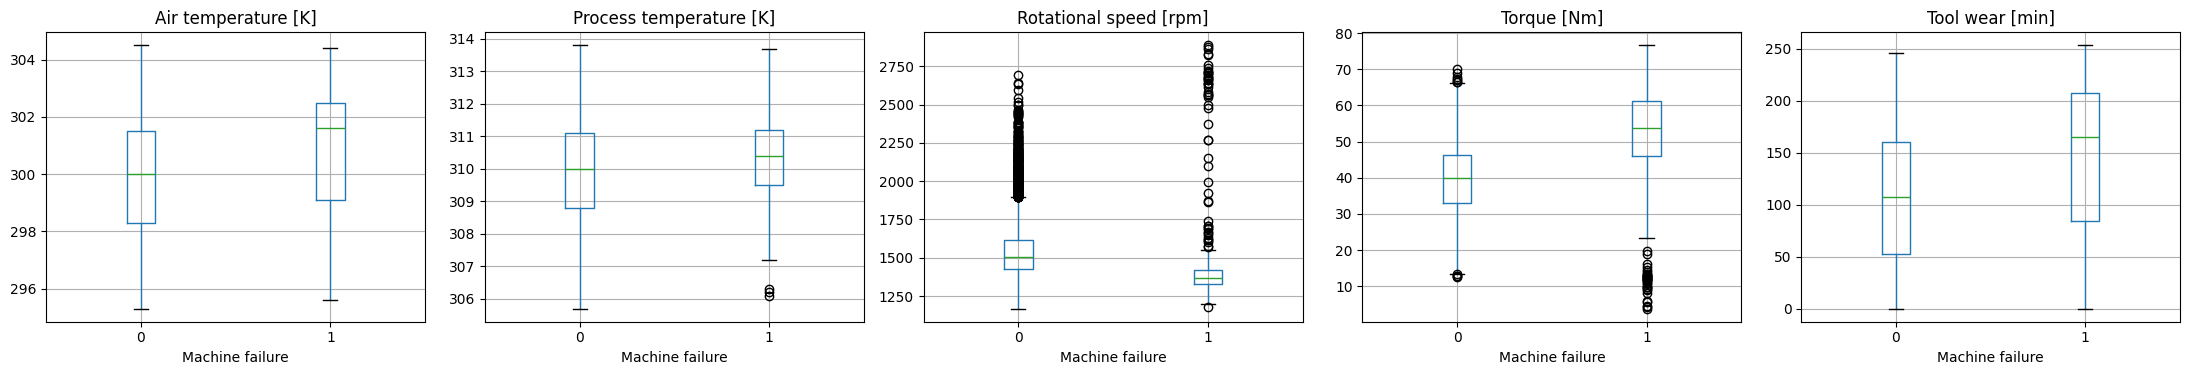

In [77]:
# Outlier detection
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for ax, col in zip(axes, cols):
    df.boxplot(column=col, by='Machine failure', ax=ax)
    ax.set_title(col)

plt.suptitle('')
plt.tight_layout()

plt.savefig('../reports/figures/outliers_by_failure.png', dpi=150)

plt.show()

In [78]:
# Remove Outliers using IQR Method

cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df_no_outliers = df.copy()

for col in cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower_bound) &
        (df_no_outliers[col] <= upper_bound)
    ]

print("Original Shape :", df.shape)
print("After Removing Outliers :", df_no_outliers.shape)

for col in cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_no_outliers[
        (df_no_outliers[col] < lower) |
        (df_no_outliers[col] > upper)
    ]

    print(col, len(outliers))

Original Shape : (10000, 12)
After Removing Outliers : (9535, 12)
Air temperature [K] 0
Process temperature [K] 0
Rotational speed [rpm] 114
Torque [Nm] 2
Tool wear [min] 0


In [79]:
# Second Pass Outlier Removal

cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for col in cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower) &
        (df_no_outliers[col] <= upper)
    ]

print("After Removing Outliers in Second Pass:",df_no_outliers.shape)

for col in cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_no_outliers[
        (df_no_outliers[col] < lower) |
        (df_no_outliers[col] > upper)
    ]

    print(col, len(outliers))

After Removing Outliers in Second Pass: (9418, 12)
Air temperature [K] 0
Process temperature [K] 0
Rotational speed [rpm] 26
Torque [Nm] 0
Tool wear [min] 0


In [80]:
# Third Pass Outlier Removal

Q1 = df_no_outliers['Rotational speed [rpm]'].quantile(0.25)
Q3 = df_no_outliers['Rotational speed [rpm]'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outliers = df_no_outliers[
    (df_no_outliers['Rotational speed [rpm]'] >= lower) &
    (df_no_outliers['Rotational speed [rpm]'] <= upper)
]

print("After Removing Outliers in Third Pass:",df_no_outliers.shape)
for col in cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_no_outliers[
        (df_no_outliers[col] < lower) |
        (df_no_outliers[col] > upper)
    ]

    print(col, len(outliers))

After Removing Outliers in Third Pass: (9392, 12)
Air temperature [K] 0
Process temperature [K] 0
Rotational speed [rpm] 11
Torque [Nm] 0
Tool wear [min] 0


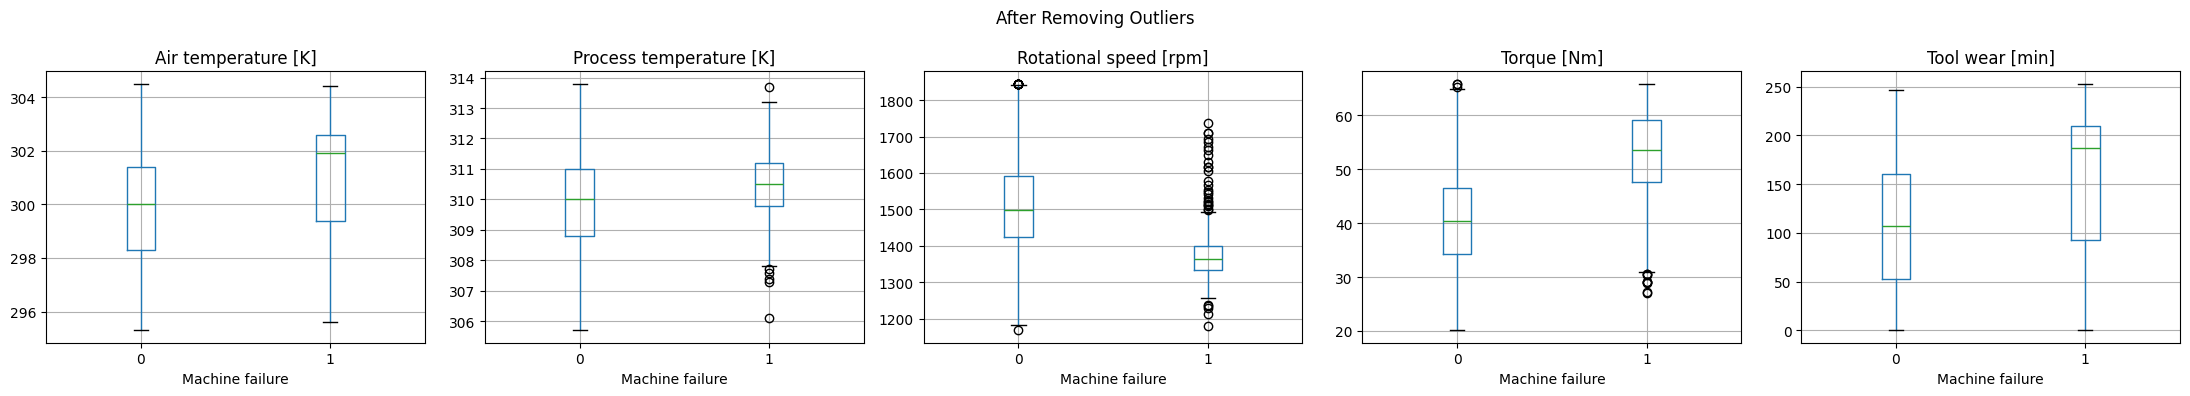

In [81]:
# Box Plot After Removing Outliers

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for ax, col in zip(axes, cols):
    df_no_outliers.boxplot(
        column=col,
        by='Machine failure',
        ax=ax
    )
    ax.set_title(col)

plt.suptitle('After Removing Outliers')
plt.tight_layout()

plt.savefig('../reports/figures/outliers_removed.png', dpi=150)

plt.show()



In [82]:
# 4. Statistical summary (numeric columns only)

print(df.describe())

       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count         10000.000000             10000.000000            10000.000000   
mean            300.004930               310.005560             1538.776100   
std               2.000259                 1.483734              179.284096   
min             295.300000               305.700000             1168.000000   
25%             298.300000               308.800000             1423.000000   
50%             300.100000               310.100000             1503.000000   
75%             301.500000               311.100000             1612.000000   
max             304.500000               313.800000             2886.000000   

        Torque [Nm]  Tool wear [min]  Machine failure           TWF  \
count  10000.000000     10000.000000     10000.000000  10000.000000   
mean      39.986910       107.951000         0.033900      0.004600   
std        9.968934        63.654147         0.180981      0.067671   
min 

In [83]:
# One-hot encode Type (L, M, H)
# Final clean dataset after outlier removal
df_clean = df_no_outliers.copy()

# One-Hot Encoding for Type column
if 'Type' in df_clean.columns:
    df_clean = pd.get_dummies(df_clean,columns=['Type'],drop_first=True
    )

print("Dataset Shape:", df_clean.shape)
print(df_clean.columns.tolist())

Dataset Shape: (9392, 13)
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L', 'Type_M']


In [84]:
# Train-Test Split
from sklearn.model_selection import train_test_split
# Features and Target
X = df_clean.drop(
    columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
)
y = df_clean['Machine failure']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("Train failure rate:", y_train.mean() * 100, "%")
print("Test failure rate:", y_test.mean() * 100, "%")

X_train Shape: (7513, 7)
X_test Shape: (1879, 7)
Train failure rate: 2.7685345401304406 %
Test failure rate: 2.7674294837679616 %


 # Univariate Analysis
 
 What is the class distribution of the machine failure target variable?

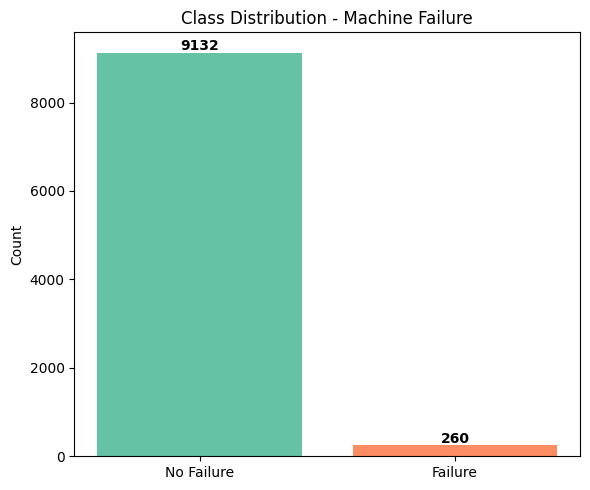

In [85]:
# Bar Chart for Target Variable

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))
counts = df_clean ['Machine failure'].value_counts()
colors = sns.color_palette("Set2")
plt.bar(
    ['No Failure', 'Failure'],
    counts.values,
    color=colors[:2]
)
plt.title('Class Distribution - Machine Failure')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_class_imbalance.png', dpi=150)
plt.show()

What are the distributions of key sensor variables across machine failure statuses?

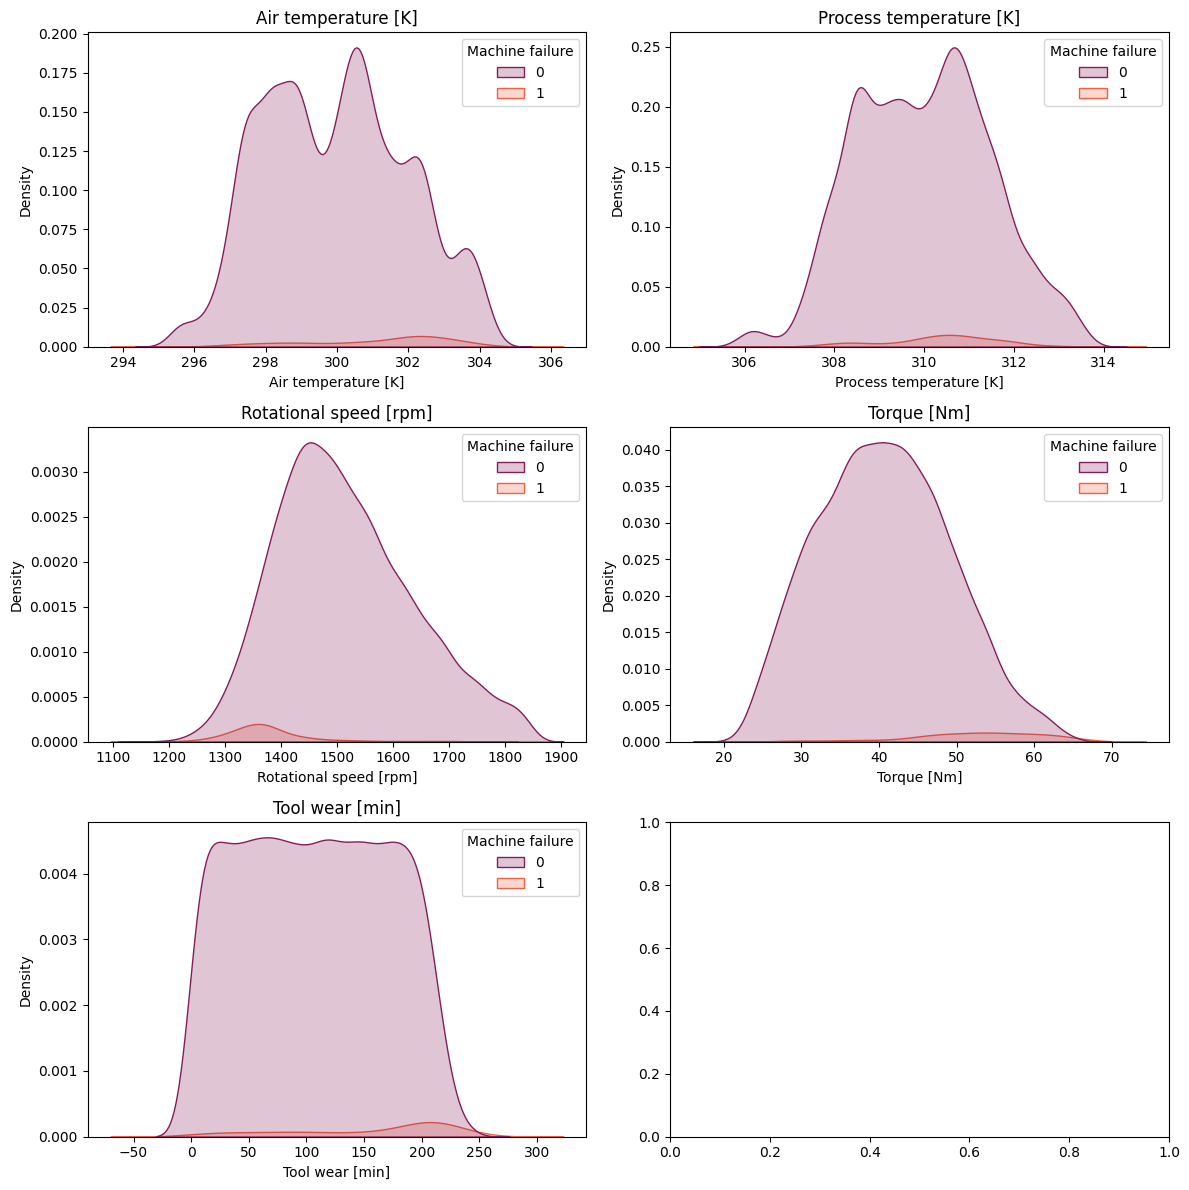

In [86]:
# KDE Distribution Plot for Sensor distributions by failure status

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

sensors = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for ax, col in zip(axes.flat, sensors):
    sns.kdeplot(
        data=df_clean,
        x=col,
        hue='Machine failure',
        fill=True,
        palette='rocket',
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

What is the distribution of rotational speed among machines?

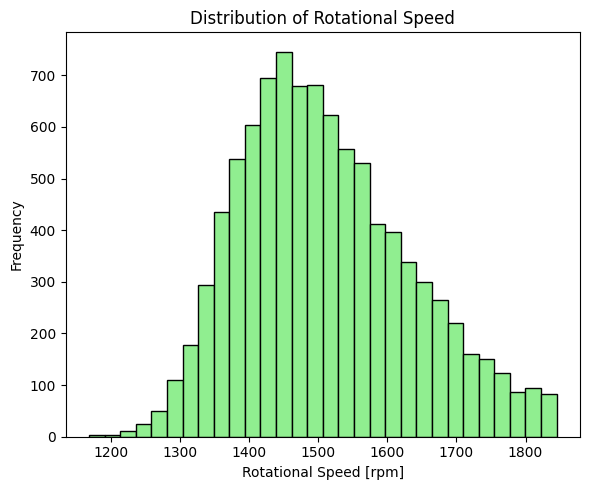

In [87]:
# Histogram for Rotational Speed Distribution

plt.figure(figsize=(6,5))

plt.hist(
    df_clean['Rotational speed [rpm]'],
    bins=30,
    color='lightgreen',
    edgecolor='black'
)

plt.title('Distribution of Rotational Speed')
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Bivariate Analysis

How does tool wear differ between failed and non-failed machines?

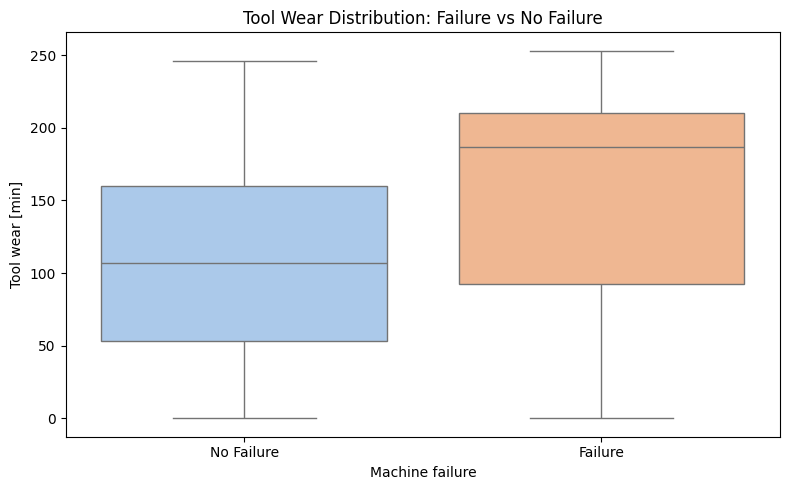

In [88]:
# Box Plot for Tool Wear Distribution by Machine Failure Status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Machine failure',
    y='Tool wear [min]',
    hue='Machine failure',
    palette='pastel',
    legend=False
)

plt.title('Tool Wear Distribution: Failure vs No Failure')
plt.xticks([0, 1], ['No Failure', 'Failure'])

plt.tight_layout()
plt.savefig('../reports/figures/03_tool_wear.png', dpi=150)
plt.show()


What is the relationship between rotational speed and torque, and how does it vary by machine failure status?

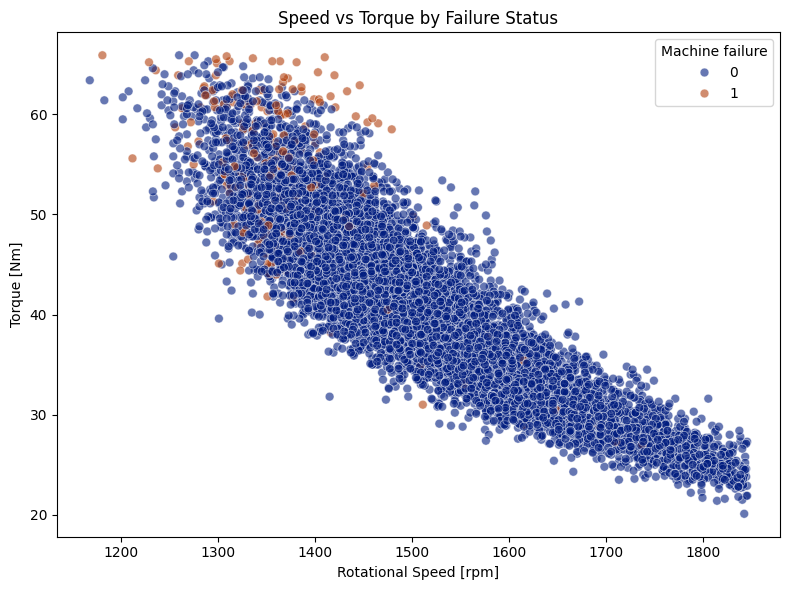

In [89]:
# Scatter Plot for Rotational Speed vs Torque by Machine Failure Status

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    palette='dark',
    alpha=0.6,
    s=40
)

plt.title('Speed vs Torque by Failure Status')
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Torque [Nm]')

plt.tight_layout()
plt.savefig('../reports/figures/04_speed_torque.png', dpi=150)
plt.show()

How does average torque vary across different tool wear levels?

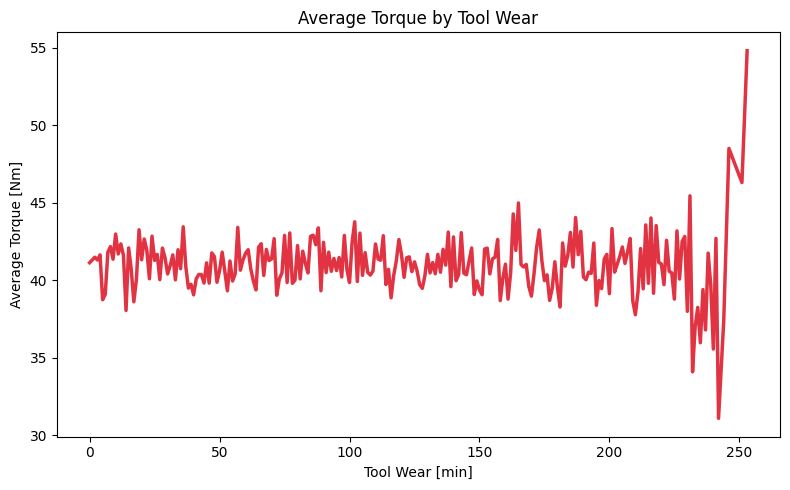

In [90]:
# Line Plot for Average Torque by Tool Wear

temp_df = df_clean.groupby('Tool wear [min]')['Torque [Nm]'].mean().reset_index()

plt.figure(figsize=(8,5))

plt.plot(
    temp_df['Tool wear [min]'],
    temp_df['Torque [Nm]'],
    color=sns.color_palette('rocket')[3],
    linewidth=2.5
)

plt.title('Average Torque by Tool Wear')
plt.xlabel('Tool Wear [min]')
plt.ylabel('Average Torque [Nm]')

plt.tight_layout()
plt.show()

# Multivariate Analysis

 What is the correlation between machine sensor features and machine failure?



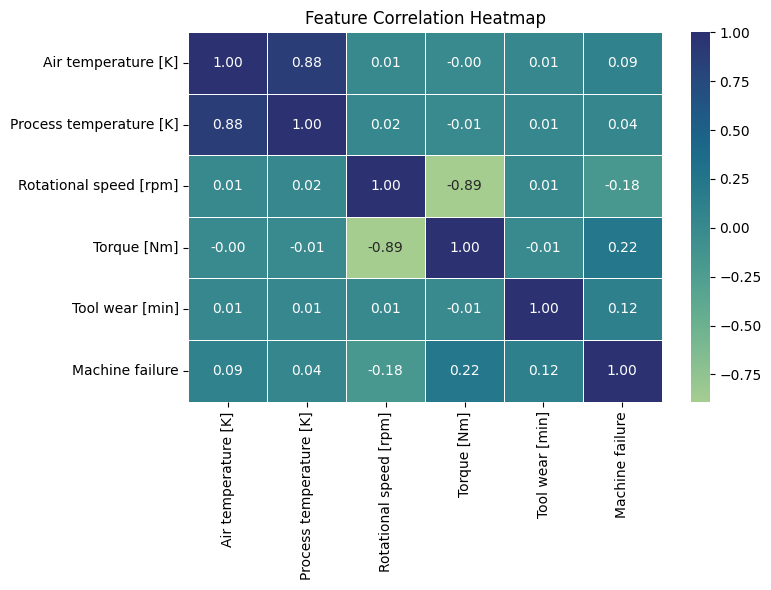

In [91]:
# Correlation Heatmap for Machine Sensor Features and Machine Failure

numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_clean[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='crest',   # palette/color map
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('../reports/figures/06_correlation.png', dpi=150)
plt.show()

How do rotational speed, torque, and tool wear jointly influence machine failure?

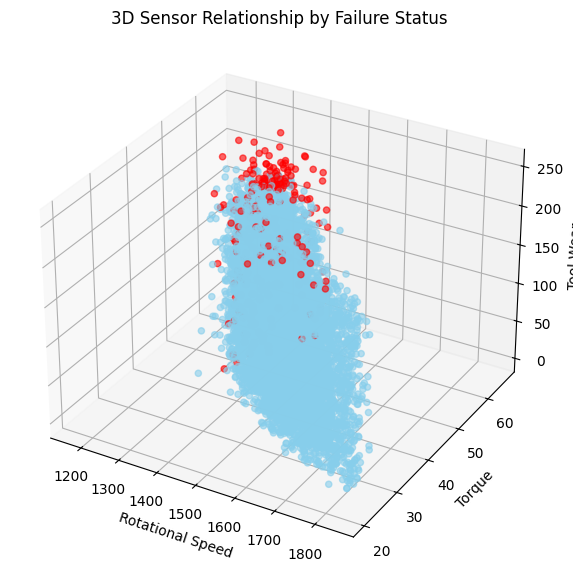

In [92]:
# 3D Scatter Plot for Speed, Torque, Tool Wear and Failure Status

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = df_clean['Machine failure'].map({0: 'skyblue', 1: 'red'})

ax.scatter(
    df_clean['Rotational speed [rpm]'],
    df_clean['Torque [Nm]'],
    df_clean['Tool wear [min]'],
    c=colors,
    alpha=0.6
)

ax.set_xlabel('Rotational Speed')
ax.set_ylabel('Torque')
ax.set_zlabel('Tool Wear')

plt.title('3D Sensor Relationship by Failure Status')
plt.show()

How do machine sensor features interact with each other and machine failure?

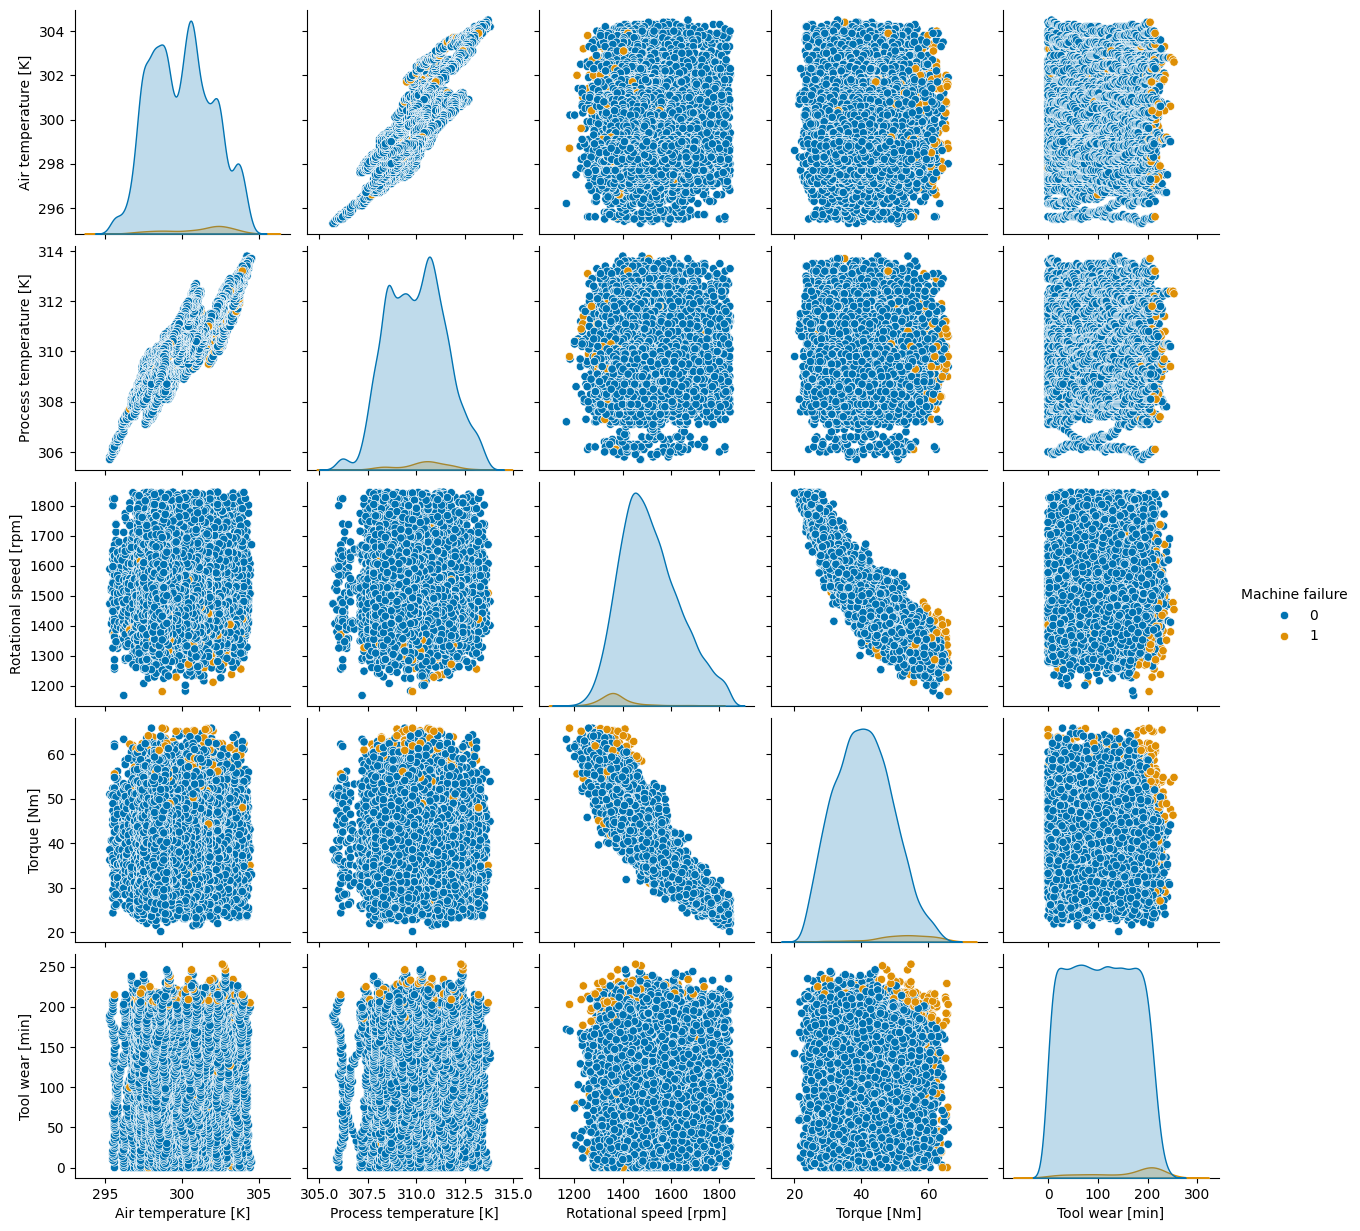

In [93]:
# Pair Plot for Sensor Features by Machine Failure Status

selected_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

sns.pairplot(
    df_clean[selected_cols],
    hue='Machine failure',
    palette='colorblind'
)

plt.show()

# Feature Engineering

In [94]:
# 1. Temperature differential — a known precursor to Heat Dissipation Failure (HDF)
df_clean['Temp_Differential'] = df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']
# Reasoning: HDF occurs specifically when this gap is too small (poor heat dissipation)

# 2. Mechanical power — torque x rotational speed (converted to consistent units)
df_clean['Power_W'] = df_clean['Torque [Nm]'] * (df_clean['Rotational speed [rpm]'] * 2 * 3.14159 / 60)
# Reasoning: Power Failure (PWF) occurs at power extremes — too low or too high.
# This single feature directly encodes the physical mechanism behind one failure type.

# 3. Tool wear stage — categorical bucket of cumulative wear
df_clean['Wear_Stage'] = pd.cut(df_clean['Tool wear [min]'],bins=[-1, 50, 150, 200, 300],labels=['Fresh', 'Moderate', 'Worn', 'Critical'])
df_clean = pd.get_dummies(df_clean, columns=['Wear_Stage'], drop_first=True)
# Reasoning: failure risk is not linear with wear — it accelerates sharply
# past a threshold. A bucketed feature lets tree models split on this directly.

# 4. Torque-to-speed ratio — proxy for mechanical strain
df_clean['Torque_Speed_Ratio'] = df_clean['Torque [Nm]'] / (df_clean['Rotational speed [rpm]'] + 1)
# Reasoning: Overstrain Failure (OSF) is essentially excess torque relative
# to speed — this ratio encodes that mechanical relationship directly.

print(df_clean[['Temp_Differential','Power_W','Torque_Speed_Ratio']].describe())


       Temp_Differential      Power_W  Torque_Speed_Ratio
count        9392.000000  9392.000000         9392.000000
mean           10.009327  6386.441348            0.027732
std             1.000080   939.178952            0.007819
min             7.600000  3877.161883            0.010906
25%             9.300000  5690.812262            0.021785
50%             9.800000  6333.314540            0.027291
75%            11.000000  7033.752975            0.033054
max            12.100000  9700.915761            0.055753


# Re-split using the engineered features


In [95]:
X = df_clean.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df_clean['Machine failure']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain Failure Rate:", y_train.mean() * 100)
print("Test Failure Rate:", y_test.mean() * 100)

X_train shape: (7513, 13)
X_test shape: (1879, 13)
y_train shape: (7513,)
y_test shape: (1879,)

Train Failure Rate: 2.7685345401304406
Test Failure Rate: 2.7674294837679616


# Model 1 — Dummy baseline (always predicts majority class)

In [96]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

print("Dummy baseline accuracy:", dummy.score(X_test, y_test))
print(classification_report(y_test, dummy_preds))
# Recall and F1 for the failure class (1) will be 0.00 — this is the point

Dummy baseline accuracy: 0.9723257051623204
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1827
           1       0.00      0.00      0.00        52

    accuracy                           0.97      1879
   macro avg       0.49      0.50      0.49      1879
weighted avg       0.95      0.97      0.96      1879



c:\Users\r\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\r\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\r\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

# Model 2 — Random Forest with class_weight (simple imbalance handling)

In [97]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # automatically upweights the minority (failure) class
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]


print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1827
           1       0.85      0.67      0.75        52

    accuracy                           0.99      1879
   macro avg       0.92      0.83      0.87      1879
weighted avg       0.99      0.99      0.99      1879



# Model 3 — XGBoost with SMOTE (advanced imbalance handling)

In [98]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib
from sklearn.metrics import classification_report
import os
from sklearn.metrics import accuracy_score

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

# IMPORTANT: Clean column names AFTER SMOTE
X_train_sm.columns = (
    X_train_sm.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
)

X_test.columns = (
    X_test.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
)

# Train model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_sm, y_train_sm)

# Prediction
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_preds))


accuracy = accuracy_score(y_test, xgb_preds)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Save files
os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_model, "../models/xgboost_model.pkl")
joblib.dump(list(X_train_sm.columns), "../models/feature_columns.pkl")

# Example threshold
best_threshold = 0.5
joblib.dump(best_threshold, "../models/best_threshold.pkl")

print("Model saved successfully!")

Before SMOTE: {0: 7305, 1: 208}
After SMOTE: {0: 7305, 1: 7305}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1827
           1       0.56      0.65      0.60        52

    accuracy                           0.98      1879
   macro avg       0.77      0.82      0.79      1879
weighted avg       0.98      0.98      0.98      1879

Accuracy: 0.9760510910058542
Accuracy (%): 97.60510910058542
Model saved successfully!



# Model comparison

In [100]:
import pandas as pd
from sklearn.metrics import f1_score, recall_score, precision_score

results = pd.DataFrame({
    'Model': ['Dummy Baseline', 'Random Forest (class_weight)', 'XGBoost (SMOTE)'],
    'Recall (Failure)': [
        recall_score(y_test, dummy_preds),
        recall_score(y_test, rf_preds),
        recall_score(y_test, xgb_preds)
    ],
    'Precision (Failure)': [
        precision_score(y_test, dummy_preds, zero_division=0),
        precision_score(y_test, rf_preds),
        precision_score(y_test, xgb_preds)
    ],
    'F1 (Failure)': [
        f1_score(y_test, dummy_preds, zero_division=0),
        f1_score(y_test, rf_preds),
        f1_score(y_test, xgb_preds)
    ]
})
print(results)
results.to_csv('../reports/model_results.csv', index=False)

                          Model  Recall (Failure)  Precision (Failure)  \
0                Dummy Baseline          0.000000             0.000000   
1  Random Forest (class_weight)          0.673077             0.853659   
2               XGBoost (SMOTE)          0.653846             0.557377   

   F1 (Failure)  
0      0.000000  
1      0.752688  
2      0.601770  


# Model Evaluation

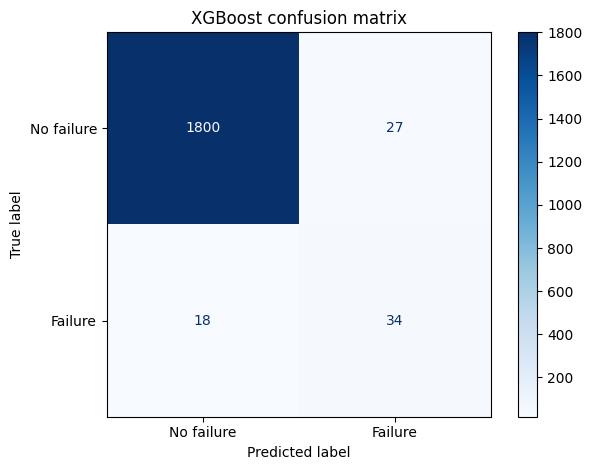

F2 score: 0.632
ROC-AUC: 0.962


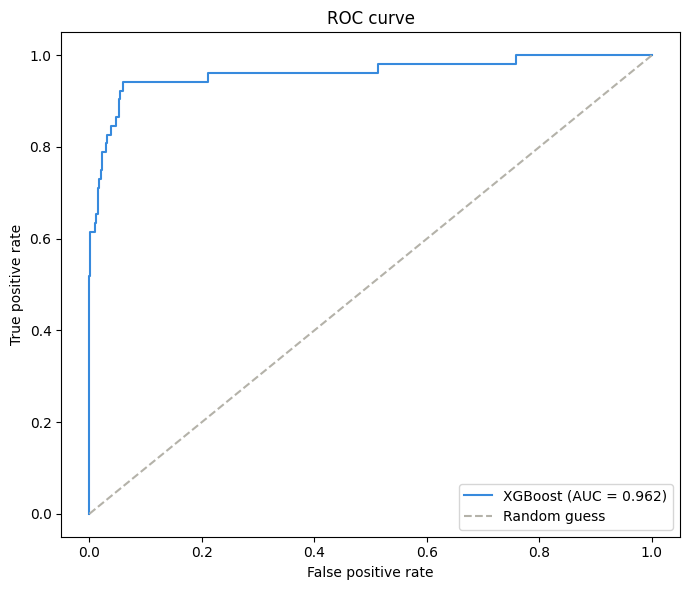

In [101]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, fbeta_score)
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No failure','Failure'])
disp.plot(cmap='Blues')
plt.title('XGBoost confusion matrix')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=150)
plt.show()

# F2 score — recall-weighted
f2 = fbeta_score(y_test, xgb_preds, beta=2)
print(f"F2 score: {f2:.3f}")

# ROC-AUC
auc = roc_auc_score(y_test, xgb_probs)
print(f"ROC-AUC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='#378ADD', label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'--',color='#B4B2A9',label='Random guess')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve.png', dpi=150)
plt.show()

# Threshold tuning

In [102]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-10)
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold for F2: {best_threshold:.3f}")
print(f"At this threshold — Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}")

# Apply the tuned threshold
xgb_preds_tuned = (xgb_probs >= best_threshold).astype(int)
print(classification_report(y_test, xgb_preds_tuned))

Best threshold for F2: 0.279
At this threshold — Precision: 0.506, Recall: 0.788
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1827
           1       0.51      0.79      0.62        52

    accuracy                           0.97      1879
   macro avg       0.75      0.88      0.80      1879
weighted avg       0.98      0.97      0.98      1879



 # Final output system

In [103]:
import joblib
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
joblib.dump(best_threshold, '../models/best_threshold.pkl')
joblib.dump(list(X_train.columns), '../models/feature_columns.pkl')

print("All artifacts saved to models/")


All artifacts saved to models/


In [104]:
import joblib

print(joblib.load("../models/feature_columns.pkl"))

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M', 'Temp_Differential', 'Power_W', 'Wear_Stage_Moderate', 'Wear_Stage_Worn', 'Wear_Stage_Critical', 'Torque_Speed_Ratio']


In [105]:
print(list(X_train_sm.columns))
import joblib

# Save the NEW feature columns
joblib.dump(list(X_train_sm.columns), "../models/feature_columns.pkl")

print("feature_columns.pkl updated successfully!")
print(joblib.load("../models/feature_columns.pkl"))

['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Type_L', 'Type_M', 'Temp_Differential', 'Power_W', 'Wear_Stage_Moderate', 'Wear_Stage_Worn', 'Wear_Stage_Critical', 'Torque_Speed_Ratio']
feature_columns.pkl updated successfully!
['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Type_L', 'Type_M', 'Temp_Differential', 'Power_W', 'Wear_Stage_Moderate', 'Wear_Stage_Worn', 'Wear_Stage_Critical', 'Torque_Speed_Ratio']
